# `Approches semi-supervisées`

__`En semi‑supervisé`__, les approches par graphe à propagation de labels représentent les données comme un graphe de similarité et diffusent les labels connus vers les nœuds non étiquetés.
:::
__`Idée de base de l'approche semi-supervisée simple itérative`__
 - Chaque exemple est un nœud, les arêtes encodent la similarité (k‑NN, RBF sur la distance, etc.).
 - Les nœuds labellisés ont des labels fixés, les nœuds non labellisés reçoivent une distribution de labels.
 - À chaque itération, les distributions se mettent à jour par moyenne pondérée des voisins, 
 - Ceci correspond à une marche aléatoire/clamping sur le graphe.
 - On converge vers une solution où les labels varient « doucement » sur le graphe (hypothèse de manifold) 
:::
`Comparaison : `
 - modèle supervisé simple 
 - self-training : simple/itératif
 - propagation label

In [1]:
%matplotlib inline

In [7]:
import umap
import sklearn
from sklearn import datasets
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pds
from sklearn.semi_supervised import LabelSpreading
from sklearn.semi_supervised import SelfTrainingClassifier

In [ ]:
path="./images/"

In [9]:
import torch
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

    
## `1. Modèle supervisé simple (baseline)`
 - on entraîne un classifieur classique (logreg, SVM, réseau, etc.) uniquement sur les données labellisées.
 - les données non labellisées sont ignorées.
 - la perf est limitée par la quantité de labels ; 
 - c’est la référence pour jauger si l'impacte Semi Supervised Learning.   

### `Récupération des données`

In [10]:
print("sklearn.__version__: ",sklearn.__version__)
sns.set_theme(context="paper", style="white")
#%time mnist = fetch_openml("mnist_784", version=1)#,return_X_y=True)
%time  fashion_mnist = fetch_openml("Fashion-Mnist")
mnist = fashion_mnist # type: ignore

sklearn.__version__:  1.7.1
CPU times: user 2.34 s, sys: 315 ms, total: 2.66 s
Wall time: 2.87 s


In [11]:
data = mnist.data 
mnist["target"] = mnist["target"].astype(int) 
target = mnist["target"]

# check que les données sont déjà mélangées
print(f"len data {len(data)} target.values[:10] : {target.values[:10]}")

len data 70000 target.values[:10] : [9 0 0 3 0 2 7 2 5 5]


In [12]:
subset_ratio = 0.30 # on ne prend pas tout pour aller plus vite
train_ratio = 0.9  # on entraine sur % du subset
labelled_ratio = 0.1 # et on utilise qu'une partie des labels (semi-sup)

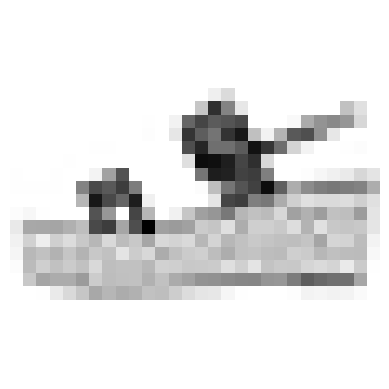

In [13]:
def plot(data,instance):
    plt.tight_layout()
    plt.axis("off")
    plt.imshow(data.iloc[instance].values.reshape(28,28),cmap="Greys")
    
plot(data,12)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    data, target, stratify=target, random_state=0, 
    train_size=train_ratio*subset_ratio, 
    test_size=(1-train_ratio)*subset_ratio
)
print(f"len train {len(X_train)} len test {len(X_test)}")

len train 18900 len test 2100


In [15]:
labelled_ratio = 0.025 # combien d'exemples avec labels ? -> 

# le modèle considèrera qu'un label -1 veut dire pas de label
y_labelled = np.copy(y_train)
y_labelled[int(labelled_ratio*len(y_train)):] = -1
counts = pds.Series(y_labelled).value_counts()
#counts.plot(kind="bar")
num_classes = counts.size -1
print(f"nombre d'items total {len(y_labelled)} labellisé : {int(labelled_ratio*len(y_train))}, unlabellisés {len(y_labelled)-int(labelled_ratio*len(y_train))} nombre de classes {num_classes}")
#counts

nombre d'items total 18900 labellisé : 472, unlabellisés 18428 nombre de classes 10


## `Modèle supervisé complet`
Pour comparer, on estime le score maxi qu'on aurait en ayant la plus grande base d'exemples possible pour l'entrainement

  + KNN simple : prendre la version sklearn
  + CNN : faites un petit cnn simple à deux couches de convolution+pooling pour avoir un meilleur modele de départ

In [26]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

In [25]:
import os

def display_confusionMatrix(y_test, y_pred, num_classes, out_dir=path, filename="conf_mat.png"):
    cm = confusion_matrix(y_test, y_pred, labels=np.arange(num_classes))
    os.makedirs(out_dir, exist_ok=True)  # crée le répertoire s'il n'existe pas
    fig, ax = plt.subplots(figsize=(3, 3))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=np.arange(num_classes))
    disp.plot(ax=ax, xticks_rotation="vertical", cmap="Blues", colorbar=False)
    plt.tight_layout()
    out_path = os.path.join(out_dir, filename)
    fig.savefig(out_path, dpi=300, bbox_inches="tight")  # sauvegarde l'image
    plt.close(fig)  # pas d'affichage

In [13]:
model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train,y_train)
y_pred = model_knn.predict(X_test)
acc = accuracy_score(y_pred,y_test)
print("Accuracy %.3f"%acc)
filename="cnfmatKNNFull.png"
display_confusionMatrix(y_test,y_pred,num_classes,filename=filename)

Accuracy 0.824


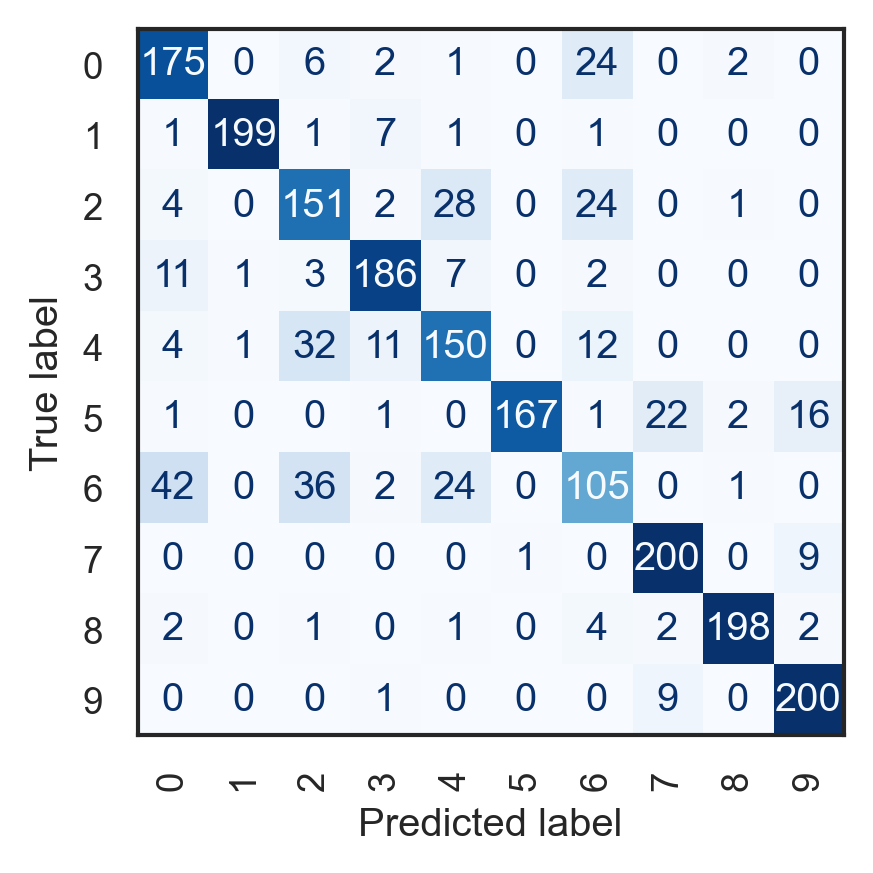

In [14]:
from IPython.display import Image, display
display(Image(os.path.join(path, filename), width=300))

In [15]:
# 1. Modèle + optimizer
del model_knn

import gc
gc.collect()

import torch
if device == "mps":
    torch.mps.empty_cache()   # sur Mac
elif device == "cuda":
    torch.cuda.empty_cache()   # sur NVidia 

SVM qui sépare tes données dans un espace de caractéristiques généré par un polynôme de degré 3 appliqué au produit scalaire, avec une échelle contrôlée par gamma=0.9, et qui fournit des probabilités de classe via predict_proba.

In [16]:
# Literal['linear', 'poly', 'rbf', 'sigmoid', 'precomputed']
# on utilise un noyau polynomial de la forme (γ⟨u,v⟩+coef0)^degree
model_svc = SVC(kernel="poly", gamma=0.9, probability=True,degree=3,coef0=0.0)
model_svc.fit(X_train,y_train)
y_pred = model_svc.predict(X_test)
acc = accuracy_score(y_pred,y_test)

print("Accuracy %.3f"%acc)
filename="cnfmatSVCFull.png"
display_confusionMatrix(y_test,y_pred,num_classes,filename=filename)

Accuracy 0.845


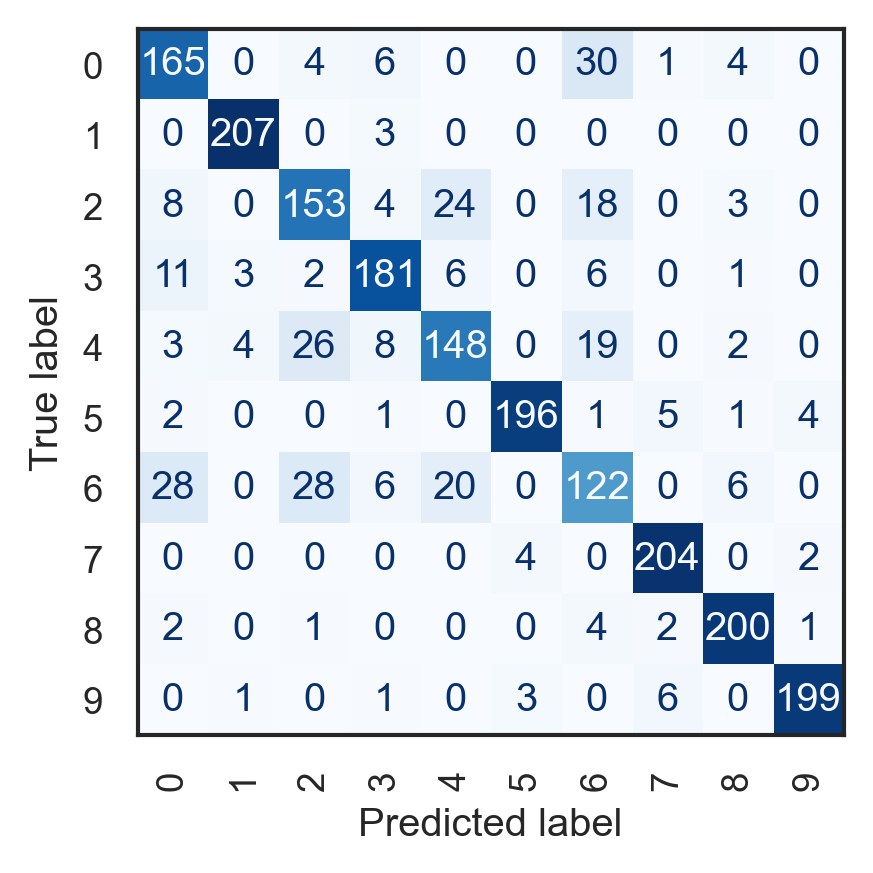

In [17]:
from IPython.display import Image, display
display(Image(os.path.join(path, filename), width=300))

In [18]:
# 1. Modèle + optimizer
del model_svc
del X_train, X_test, y_train, y_test

import gc
gc.collect()

import torch
if device == "mps":
    torch.mps.empty_cache()   # sur Mac
elif device == "cuda":
    torch.cuda.empty_cache()   # sur NVidia 

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SmallCNN(nn.Module):
    def __init__(self, in_channels=1, num_classes=10):
        super().__init__()
        # Bloc 1 : Conv + ReLU + MaxPool
        self.conv1 = nn.Conv2d(in_channels, 16, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Bloc 2 : Conv + ReLU + MaxPool
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Taille après deux poolings 2×2 : 28 -> 14 -> 7
        self.fc = nn.Linear(32 * 7 * 7, num_classes)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))   # [B,16,14,14]
        x = self.pool2(F.relu(self.conv2(x)))   # [B,32,7,7]
        x = x.view(x.size(0), -1)               # flatten
        x = self.fc(x)
        return x

In [20]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

# 1) DataFrame -> ndarray
X = data.to_numpy().astype(np.float32)   # shape (70000, 784)
y = target.to_numpy().astype(int)

# 2) Normalisation [0,1]
X = X / 255.0

# 3) Reshape en (N, 1, 28, 28)
#print(np.sqrt(len(X[0])))
X = X.reshape(-1, 1, 28, 28)

# 4) split train / test
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=10000, random_state=42, stratify=y)

class FashionDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)              # float32
        self.y = torch.from_numpy(y).long()       # int64 pour CrossEntropyLoss

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = FashionDataset(X_train, y_train)
test_dataset  = FashionDataset(X_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False)


In [21]:
model_cnn = SmallCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_cnn.parameters(), lr=1e-3)

In [22]:
import torch.nn as nn
import torch.nn.functional as F

for epoch in range(5):
    model_cnn.train()
    running_loss = 0.0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model_cnn(Xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * Xb.size(0)
        
    print(f"Epoch {epoch+1}, loss = {running_loss / len(train_dataset):.4f}")

Epoch 1, loss = 0.5245
Epoch 2, loss = 0.3503
Epoch 3, loss = 0.3091
Epoch 4, loss = 0.2834
Epoch 5, loss = 0.2665


In [23]:
model_cnn.eval()
correct = 0
total = 0
y_pred=[]
all_preds = []
all_targets = []

with torch.no_grad():
    for Xb, yb in test_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        logits = model_cnn(Xb)
        preds = logits.argmax(dim=1)
        y_pred.append(preds)
        correct += (preds == yb).sum().item()
        total += yb.size(0)
        all_preds.append(preds.cpu().numpy())
        all_targets.append(yb.numpy())

y_pred = np.concatenate(all_preds)
y_test = np.concatenate(all_targets)
print(f"Test accuracy: {correct / total:.3f}")
filename="cnfmatCNNFull.png"
display_confusionMatrix(y_test,y_pred,num_classes,filename=filename)

Test accuracy: 0.897


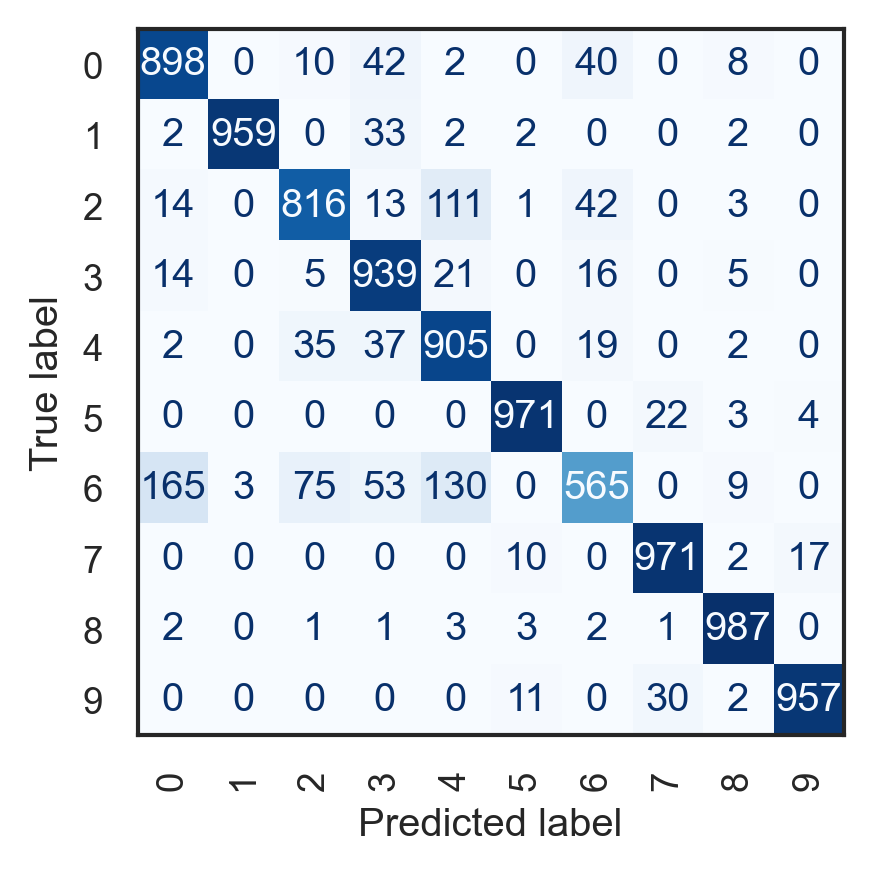

In [24]:
from IPython.display import Image, display
display(Image(os.path.join(path, filename), width=300))

_Axe vertical = True label (classe réelle),_  _Axe horizontal = Predicted label (classe prédite)._

In [ ]:
# 1. Modèle + optimizer
del model_cnn
del optimizer
del X_train, X_test, y_train, y_test

import gc
gc.collect()

import torch
if device == "mps":
    torch.mps.empty_cache()   # sur Mac
elif device == "cuda":
    torch.cuda.empty_cache()   # sur NVidia 

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    data, target, stratify=target, random_state=0, 
    train_size=train_ratio*subset_ratio, 
    test_size=(1-train_ratio)*subset_ratio
    )

In [18]:
labelled_ratio = 0.025 # combien d'exemples avec labels ? -> 
# le modèle considèrera qu'un label -1 veut dire pas de label
y_labelled = np.copy(y_train)
y_labelled[int(labelled_ratio*len(y_train)):] = -1
counts = pds.Series(y_labelled).value_counts()
#counts.plot(kind="bar")
num_classes = counts.size -1

### `Modèle self-trained`
`1. Self‑training simple / itératif`
Utiliser le modèle supervisé comme “Evaluateur” pour s’auto‑alimenter avec des pseudo‑labels prédits.

__Principe (pseudo‑labelling itératif) :__
- Entraîner un modèle supervisé sur les données labellisées uniquement (peu de données labellisées).
- Prédire les labels du non‑labellé, garder seulement les prédictions à forte confiance (ex. proba > 0.9).
- Ajouter ces exemples pseudo‑labellés au jeu de train, réentraîner.
- Répéter 2–3 jusqu’à convergence ou plus rien de suffisamment confiant.

`Caractéristiques :`
- __Mécanisme :__ 
    - Cadre “modèle supervisé avec un jeu de train qui augmente”, l’architecture du modèle ne change pas.
- __Avantages :__ Facile à plugger sur un modèle (CNN, Transformer, etc.). 
    - Peut dépasser nettement le baseline si le modèle de départ est déjà raisonnablement bon.
- __Inconvénients :__ 
    - Risque d’amplifier les erreurs (confirmation biaisée) si les pseudo‑labels sont mauvais. 
    - Sensible aux seuils de confiance, à l’ordre d’ajout des exemples, etc.

In [19]:
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.semi_supervised import LabelSpreading, LabelPropagation

In [28]:
def self_trainedFunction(X_train, y_labelled, X_test, y_test,
                         threshold=0.9, max_iter=None,n_neighbors=5):
    # API récente : utiliser `estimator=` et non `base_estimator=`
    st = SelfTrainingClassifier(
        KNeighborsClassifier(n_neighbors=n_neighbors),
        threshold=threshold,
        criterion="threshold",
        max_iter=max_iter,
        verbose=False
    )
    st.fit(X_train, y_labelled)
    y_pred = st.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    return st, y_pred, acc

In [37]:
def self_trainedModel(X_train,y_labelled,X_test,y_test,n_neighbors=5 ):
    # on compare à entrainement sur la petite base supervisée
    mask = (y_labelled != -1) 
    modelbase_KNN = KNeighborsClassifier(n_neighbors=n_neighbors)
    modelbase_KNN.fit(X_train[mask],y_labelled[mask])
    y_pred = modelbase_KNN.predict(X_test)
    acc = accuracy_score(y_pred,y_test)
    return modelbase_KNN, y_pred, acc

On tient compte uniquement des items labellisés, accuracy 0.7167


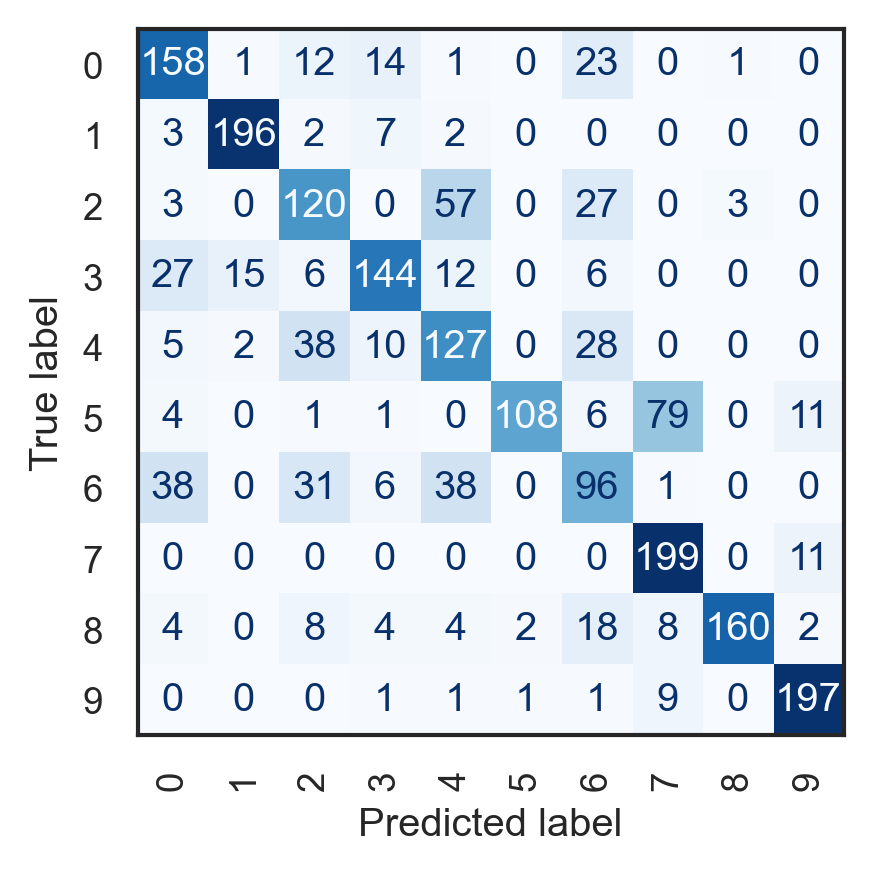

In [38]:
modelbase_KNN, y_pred, acc = self_trainedModel(X_train,y_labelled,X_test,y_test,n_neighbors=5 )

print(f"On tient compte uniquement des items labellisés, accuracy {acc:.4f}")
filename="cnfmatKNNSelftTrng.png"
display_confusionMatrix(y_test,y_pred,num_classes,filename=filename)
from IPython.display import Image, display
display(Image(os.path.join(path, filename), width=300))

Accuracy 0.723


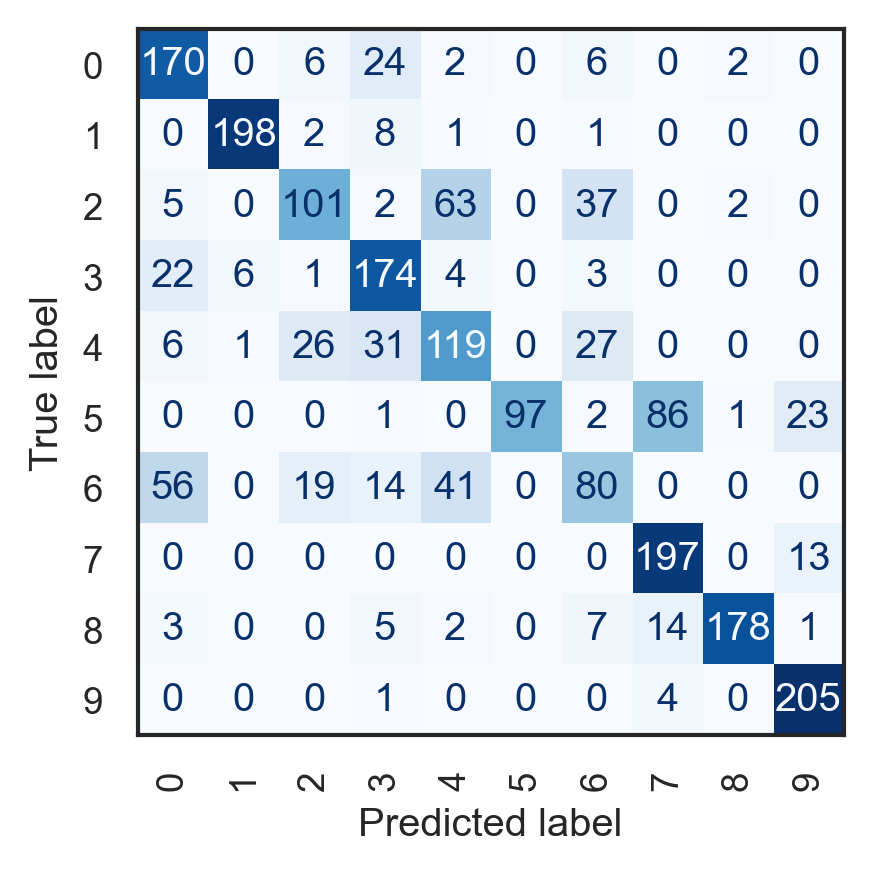

In [39]:
st, y_pred, acc = self_trainedFunction(
                X_train, y_labelled, X_test, y_test,
                threshold=0.9, max_iter=None,n_neighbors=5)

print("Accuracy %.3f"%acc)
filename="cnfmatKNNSelftTrng.png"
display_confusionMatrix(y_test,y_pred,num_classes,filename=filename)
from IPython.display import Image, display
display(Image(os.path.join(path, filename), width=300))

In [ ]:
# 1. Modèle + optimizer
del modelbase_KNN

import gc
gc.collect()

## `Mode LabelPropagation`
`2. LabelPropagation`
Plutôt que de réentraîner le modèle à chaque itération, on définit un graphe de similarité sur toutes les données et on “diffuse” les labels des points labellisés vers les autres.

__Principe (graphe fixe) :__
 - La fonction construit un graphe d’affinité W sur tous les points (RBF, k‑NN…).
 - Initialise un vecteur de labels Y (_labels one‑hot pour les points annotés, “inconnu” pour les autres_).
 - Itére la mise à jour de type Y←SY avec S dérivé de W, en gardant les labels des points annotés fixes.
 - À la convergence, elle affecte à chaque nœud la classe de probabilité maximale.

`Caractéristiques :`
- __Mécanisme :__ 
    - Utilise la structure géométrique/manifold via le graphe. 
    - Faux modèle paramétrique global au sens d’un $fθ(x)$ appris par gradient, sur scikit-learn standard.
    - Construit un graphe non orienté sur les données, à partir d’un noyau RBF 
    - Complètement connecté, pondéré par $exp(−γ||x_i − x_j||^2))$ ou KNN (graphe parcimonieux). 
    - Les labels connus sont injectés sur quelques nœuds, 
    - Résout un problème de diffusion/regularisation de type « smooth signal on graph », 
    - Typiquement via une itération $F^{t+1}=SF^t$ avec la contrainte de garder fixes les labels connus.
    - « La manifold assumption, utilisée implicitement : revient à supposer que des points connectés ou voisins sur le graphe appartiennent à la même classe, de sorte que le label varie de façon lisse.

- __Avantages :__
  - `Bon si le graphe est clusterisé (clusters compacts, bien séparés), peu de labels`.
  - Ne requiert pas de choisir une architecture (_peu de paramètres (kernel, gamma, k)_).
- __Inconvénients :__
  - Dépend fortement du graph building (choix de k, gamma RBF, métrique).
  - `Peut être coûteux en mémoire pour de très gros jeux (graphe dense)`.
  - Sur des données de haute dimension/complexes, LP seul est moins bon que self‑training + modèle riche.

`3. Environnement scikit-learn / LabelPropagation vs LabelSpreading`
 - _`LabelSpreading`_ : 
    - variante avec régularisation qui « relâche » un peu les labels initiaux , souvent plus stable numériquement, sur la même idée de base de LabelPropagation.
    - Utilise la Laplacienne normalisée et une « soft clamping » des labels (les labels des nœuds labellisés peuvent légèrement bouger, plus robuste au bruit).

`5. Un modèle plus « global »` 
 - _`Approches GLP (Generalized Label Propagation)`_ : 
   - décomposent en signal + filtre de graphe + classifieur, 
   - ce qui permet de brancher un classifieur paramétrique (logistic regression, MLP) après un lissage graph-based.  

 - _`GCN / GNN`_ : 
  - réinterprète la propagation comme une convolution de graphe paramétrique, avec des poids entraînés par backprop, 
  - donne un vrai $f_θ$ global sur les nœuds (et parfois hors graphe si on sait étendre la convolution).  

__`Conclusion`__ : LP pur est très bon pour exploiter la structure de variété dans un cadre transductif, mais dès que tu veux un modèle explicitement paramétrique ou inductif, il faut passer soit à une version « LP + classifieur », soit à une GCN/GNN.


    

 Aspect | Supervised simple | Self‑training | LabelPropagation |
| --- | --- | --- | --- |
| Utilise le non‑labellé ? | Non | Oui, via pseudo‑labels | Oui, via graphe de similarité |
| Mécanisme clé | Entraînement une fois sur les données labellisées uniquement | Ré‑entraînement itératif avec ajout progressif de pseudo‑labels sûrs | Diffusion des labels sur un graphe de similarité fixé |
| Où est la “structure” ? | Apprise uniquement à partir des points labellisés | Apprise par le modèle, enrichie par les pseudo‑labels générés | Imposée par la construction du graphe (RBF, k‑NN, métrique) |
| Avantage typique | Simplicité, stabilité, peu de sources d’erreur | Fort gain possible si le modèle initial est déjà raisonnablement bon | Efficace avec très peu de labels si le graphe reflète bien les clusters |
| Risque principal | Sous‑apprentissage si très peu de labels | Auto‑renforcement d’erreurs (pseudo‑labels faux) | Propagation globale d’erreurs si le graphe est mal construit |

Dans la version “classique” de LabelPropagation (type scikit‑learn), la mise à jour se fait comme une moyenne pondérée des labels voisins, pondérée par les poids du graphe.

Formule (intuitive)
$$ y_i^{(t+1)}=\sum_j S_{ij}y^{(t)} \text{, avec } S_{ij}=\large \frac{W{ij}}{\sum_k W_{ik}} $$
On note : 
- $W_{ij}$ le poids de l’arête entre les nœuds i et j (affinité, issue de ton RBF ou k‑NN). 
- $y_{jy}$ le vecteur de scores de labels au nœud j (une coordonnée par classe

In [208]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.semi_supervised import LabelPropagation
from sklearn.neighbors import kneighbors_graph

In [210]:
from sklearn.metrics.pairwise import rbf_kernel

def label_prop_function(kernel, X, y, n_neighbors=5, gamma=1.0, flag=False):
    label_prop = LabelPropagation(kernel=kernel,n_neighbors=n_neighbors,max_iter=1000,gamma=gamma)
    w=[]
    label_prop.fit(X, y)
    y_propag = label_prop.transduction_

    if kernel == "knn":
        # graphe KNN binaire
        W = kneighbors_graph(X, n_neighbors=n_neighbors,mode="connectivity", include_self=False)
        G = nx.from_scipy_sparse_array(W)
    elif kernel == "rbf":
        # matrice RBF dense
        K = rbf_kernel(X, gamma=gamma)           # K_ij = exp(-gamma ||xi-xj||^2)[web:181][web:183]
        np.fill_diagonal(K, 0.0)                 # pas de boucle i->i
        G = nx.from_numpy_array(K)               # poids = K_ij
        W = K
    else:
        raise ValueError("kernel doit être 'knn' ou 'rbf'")
    if flag:
       print(f"W matrice de similarité RBF symétrique construite avec un noyau gaussien sur les points {X.transpose()}.")
       for i in range(W.shape[0]):
            row = W[i].toarray().ravel() if hasattr(W, "toarray") else W[i]
            print([f"{v:.4f}" for v in row])

    return label_prop,y_propag, W, G

__`1. Le modèle construit son propre graphe d’affinité à partir des éléments X`__
__`kernel="rbf"`__.  
sklearn construit en interne le graphe de similarité à partir de X et propage les labels des nœuds y != -1.
Les poids sont donnés par un noyau gaussien sur les distances $W_{ij}=exp(−γ||x_i−x_j||^2)$
 - Plus $x_i$ et $x_j$ sont proches en norme euclidienne, plus W_{ij} est grand.
 - Plus ils sont loin, plus $W_{ij}$ tend vers 0.
 - gamma contrôle l’échelle : grand gamma → noyau très local, petit gamma → plus global.

__`kernel="knn"`__
Les poids viennent du graphe k‑plus proches voisins :
 - On trouve pour chaque point ses _n_neighbors_ les plus proches en distance euclidienne.
 - On crée une matrice de voisinage (souvent binaire) :

$$W_{ij} = \begin{cases} 1, & \text{si } x_j \text{ est parmi les k plus proches voisins de } x_i \text{ (ou vice-versa)},\\ 0, & \text{sinon.} \end{cases}$$
 - Puis on symétrise (grosso modo $W←(W+W^⊤)/2)$.

__`2. Principe de pondération des éléments non labellisés`:__ 
Dans la version “classique” de LabelPropagation (type scikit‑learn), la mise à jour se fait comme une moyenne pondérée des labels voisins, pondérée par les poids du graphe.

Formule (intuitive)
$$ y_i^{(t+1)}=\sum_j S_{ij}y^{(t)} \text{, avec } S_{ij}=\large \frac{W{ij}}{\sum_k W_{ik}} $$
On note : 
- $W_{ij}$ le poids de l’arête entre les nœuds i et j (affinité, issue de ton RBF ou k‑NN). 
- $y_{jy}$ le vecteur de scores de labels au nœud j (une coordonnée par classe).


__`3. Exemple de Graphe et Labels initiaux`:__ 
 - Nœud 1 :label connu Rouge, 
 - Nœud 5 :label connu Bleu, 
 - Nœuds 2,3,4 : non étiquetés.   
`3.1 Pondération des arêtes effectuée par la fonction LabelPropagation de sklearn` :  
  - $w_{1,2}=1$, $w_{2,3}=0,5$, $w_{3,4}=1$, $w_{4,5}=1$.  
__`4. Le mécanisme de diffusion des labels répond au mécanisme suivant` :__ 
On normalise par ligne pour obtenir les poids de combinaison $ \small S_{ij}=\large \frac{W{ij}}{\sum_k W_{ik}}$
`Sommes/nœud` : 
 - $\small \sum_k W_{1k}=1,5$, 
 - $\small \sum_k W_{2k}=1+0,5=1,5$, 
 - $\small \sum_k W_{3k}=0,5+1=2$, 
 - $\small \sum_k W_{4k}=1+1=2$, 
 - $\small \sum_k W_{5k}=1$.  
`Donc :`
  - $S_{2,1}=1/1,5=2/3$
  - $S_{2,3}=0,5/1,5=1/3$
  - $S_{2,1}=0,5/1,5=1/3$
  - $S_{3,4}=1/1,5=2/3$
  - $S_{4,3}=1/2$
  - $S_{4,5}=1/2$  
`5. Représentation des labels comme des vecteurs`
On a 2 classes, on code chaque nœud par un vecteur $(p_R,p_B)$ :
- Nœud 1 (R connu) : (1,0)
- Nœud 5 (B connu) : (0,1)
- Nœuds 2,3,4 (inconnus) : initialement (0,0) ou, pour être neutre, (0,5,0,5). 
- Prenons (0,0) et on ré‑injecte les labels connus à chaque itération.
`6. Itération de propagation`
Version simple : 
- pour les nœuds non étiquetés, on fait la moyenne pondérée des voisins ; 
- pour les nœuds étiquetés (1 et 5), on les remet à leur label initial après la mise à jour.
__Itération t=0→t=1__
 - Nœud 1 : reste (1,0) (source).
 - Nœud 5 : reste (0,1).
 - Nœud 2 : voisins 1 et 3

    - Label de 1 : (1,0)
    - Label de 3 : (0,0)
    - Poids normalisés : $S_{2,1}=\frac{2}{3}\text{ , } S_{2,3}=\frac{1}{3}\text{ => }y_2^{(1)}=\frac{2}{3}(1,0)+\frac{1}{3}(0,0)=(\frac{2}{3},0)$
 - Nœud 3 : voisins 2 et 4, mais au temps 0 ils sont (0,0), donc $y_{3}^{(1)}=(0,0)$.
 - Nœud 4 : voisins 3 et 5.
   - Label de 3 : (0,0)
   - Label de 5 : (0,1)
   - Poids : $S_{4,3}=\frac{1}{2}\text{ , } S_{4,5}=\frac{1}{2}\text{ => } y_{4}^{(1)}=\frac{1}{2}(0,0)+ \frac{1}{2}(0,1)=(0, \frac{1}{2})$

`Après 1 itération :`
 - rappel : $\small y_i^{(t+1)}=\sum_j S_{ij}y^{(t)} \text{, avec } S_{ij}=\large \frac{W{ij}}{\sum_k W_{ik}}$ 
 - $ y_1 =(1,0) \text{ , } y_2≈(0.67,0) \text{ , } y_2≈(0.67,0) \text{ , } y_3=(0,0) \text{ , }y_4=(0,0.5) \text{ , } y_5=(0,1)$
 - On voit déjà la `“zone rouge”` se diffuser vers 2 et la “zone bleue” vers 4.
`4. Itération suivante (esquisse)`
Itération $t=1→t=2$ (toujours en gardant 1 et 5 fixés) :
 - Nœud 2 : voisin 1 (R fort) et 3 (encore neutre)→ reste très proche de rouge.
 - Nœud 3 : voisins 2 (devenu rouge) et 4 (bleu)

   - $S_{3,2}=\frac{1}{3}\text{ , }S_{3,4}=\frac{2}{3}\text{ => }y_3^{(2)}=\frac{1}{3}y_2^{(1)}+ \frac{2}{3}y_4^{(1)}≈ \frac{1}{3}(0.67,0)+ \frac{2}{3}(0,0.5)≈(0,22,0.33)$
   - Donc 3 devient “mixte”, légèrement plus bleu que rouge.

Si on continue ces itérations, on obtient un champ de labels “lissé” entre les sources 1 (Rouge) et 5 (Bleu). Le nœud 2 finira fortement rouge, 4 fortement bleu, 3 au milieu en probas intermédiaires.

En pratique, l’algorithme sur graphe fixe fait exactement ce type de diffusion itérative, avec souvent une formulation matricielle 
 - $Y^{(t + 1)}=\alpha SY^{(t)} + (1−\alpha)Y(0)$ pour conserver fermement les labels connus.   


__`3. Exemple de Graphe et Labels initiaux`:__ 
 - Nœud 1 :label connu Rouge, 
 - Nœud 5 :label connu Bleu, 
 - Nœuds 2,3,4 : non étiquetés.   
`3.1 Pondération des arêtes effectuée par la fonction LabelPropagation de sklearn` :  
  - $w_{1,2}=1$, $w_{2,3}=0,5$, $w_{3,4}=1$, $w_{4,5}=1$.  
__`4. Le mécanisme de diffusion des labels répond au mécanisme suivant` :__ 
On normalise par ligne pour obtenir les poids de combinaison $ \small S_{ij}=\large \frac{W{ij}}{\sum_k W_{ik}}$
`Sommes/nœud` : 
 - $\small \sum_k W_{1k}=1,5$, 
 - $\small \sum_k W_{2k}=1+0,5=1,5$, 
 - $\small \sum_k W_{3k}=0,5+1=2$, 
 - $\small \sum_k W_{4k}=1+1=2$, 
 - $\small \sum_k W_{5k}=1$.  
`Donc :`
  - $S_{2,1}=1/1,5=2/3$
  - $S_{2,3}=0,5/1,5=1/3$
  - $S_{2,1}=0,5/1,5=1/3$
  - $S_{3,4}=1/1,5=2/3$
  - $S_{4,3}=1/2$
  - $S_{4,5}=1/2$  
`5. Représentation des labels comme des vecteurs`
On a 2 classes, on code chaque nœud par un vecteur $(p_R,p_B)$ :
- Nœud 1 (R connu) : (1,0)
- Nœud 5 (B connu) : (0,1)
- Nœuds 2,3,4 (inconnus) : initialement (0,0) ou, pour être neutre, (0,5,0,5). 
- Prenons (0,0) et on ré‑injecte les labels connus à chaque itération.
`6. Itération de propagation`
Version simple : 
- pour les nœuds non étiquetés, on fait la moyenne pondérée des voisins ; 
- pour les nœuds étiquetés (1 et 5), on les remet à leur label initial après la mise à jour.
__Itération t=0→t=1__
 - Nœud 1 : reste (1,0) (source).
 - Nœud 5 : reste (0,1).
 - Nœud 2 : voisins 1 et 3

    - Label de 1 : (1,0)
    - Label de 3 : (0,0)
    - Poids normalisés : $S_{2,1}=\frac{2}{3}\text{ , } S_{2,3}=\frac{1}{3}\text{ => }y_2^{(1)}=\frac{2}{3}(1,0)+\frac{1}{3}(0,0)=(\frac{2}{3},0)$
 - Nœud 3 : voisins 2 et 4, mais au temps 0 ils sont (0,0), donc $y_{3}^{(1)}=(0,0)$.
 - Nœud 4 : voisins 3 et 5.
   - Label de 3 : (0,0)
   - Label de 5 : (0,1)
   - Poids : $S_{4,3}=\frac{1}{2}\text{ , } S_{4,5}=\frac{1}{2}\text{ => } y_{4}^{(1)}=\frac{1}{2}(0,0)+ \frac{1}{2}(0,1)=(0, \frac{1}{2})$

`Après 1 itération :`
 - rappel : $\small y_i^{(t+1)}=\sum_j S_{ij}y^{(t)} \text{, avec } S_{ij}=\large \frac{W{ij}}{\sum_k W_{ik}}$ 
 - $ y_1 =(1,0) \text{ , } y_2≈(0.67,0) \text{ , } y_2≈(0.67,0) \text{ , } y_3=(0,0) \text{ , }y_4=(0,0.5) \text{ , } y_5=(0,1)$
 - On voit déjà la `“zone rouge”` se diffuser vers 2 et la “zone bleue” vers 4.
`4. Itération suivante (esquisse)`
Itération $t=1→t=2$ (toujours en gardant 1 et 5 fixés) :
 - Nœud 2 : voisin 1 (R fort) et 3 (encore neutre)→ reste très proche de rouge.
 - Nœud 3 : voisins 2 (devenu rouge) et 4 (bleu)

   - $S_{3,2}=\frac{1}{3}\text{ , }S_{3,4}=\frac{2}{3}\text{ => }y_3^{(2)}=\frac{1}{3}y_2^{(1)}+ \frac{2}{3}y_4^{(1)}≈ \frac{1}{3}(0.67,0)+ \frac{2}{3}(0,0.5)≈(0,22,0.33)$
   - Donc 3 devient “mixte”, légèrement plus bleu que rouge.

Si on continue ces itérations, on obtient un champ de labels “lissé” entre les sources 1 (Rouge) et 5 (Bleu). Le nœud 2 finira fortement rouge, 4 fortement bleu, 3 au milieu en probas intermédiaires.

En pratique, l’algorithme sur graphe fixe fait exactement ce type de diffusion itérative, avec souvent une formulation matricielle 
 - $Y^{(t + 1)}=\alpha SY^{(t)} + (1−\alpha)Y(0)$ pour conserver fermement les labels connus.   


In [211]:
# 5 points sur une ligne en 1D (on peut les embedder en 2D si on veut)
# dans un vrai problème, X serait ton vecteur de features (MFCC, pixels, embeddings, etc.).
X = np.array([[0.0],[1.0],[2.0],[3.0],[4.0]])
# labels : 1 = R, 5 = B, les autres inconnus
# on code R=0, B=1 pour scikit-learn
y = np.array([1, -1, 0, -1, 0])
kernel="knn"
n_neighbors=2
gamma=1.0
filename="labelpropagKNN_Test.png"
label_prop,y_propag, W, G = label_prop_function(
                                    kernel, X, y, 
                                    n_neighbors=n_neighbors, 
                                    gamma=1.0, flag=True
                                    )

W matrice de similarité RBF symétrique construite avec un noyau gaussien sur les points [[0. 1. 2. 3. 4.]].
['0.0000', '1.0000', '1.0000', '0.0000', '0.0000']
['1.0000', '0.0000', '1.0000', '0.0000', '0.0000']
['0.0000', '1.0000', '0.0000', '1.0000', '0.0000']
['0.0000', '0.0000', '1.0000', '0.0000', '1.0000']
['0.0000', '0.0000', '1.0000', '1.0000', '0.0000']


In [212]:
import os
import matplotlib.pyplot as plt
import networkx as nx

def display_graph(kernel, X, G, y_propag, n_neighbors,out_dir=path,filename="image",figsize=(13, 1)):
    os.makedirs(out_dir, exist_ok=True)
    # Position des noeuds : ici on se sert directement de la coordonnée x
    X_arr = np.asarray(X)          # marche pour DataFrame ou ndarray
    pos = {i: (X_arr[i, 0], 0.0) for i in range(X_arr.shape[0])}

    # Couleurs des nœuds selon label propagé
    node_colors = ["red" if lab == 0 else "blue" for lab in y_propag]
    # Labels des nœuds : numéro de noeud
    node_labels = {i: f"{i}" for i, _ in enumerate(y_propag)}
    fig, ax = plt.subplots(figsize=figsize)
    # Dessin des nœuds
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=800, ax=ax)
    # Dessin des arêtes
    nx.draw_networkx_edges(G, pos, edge_color="black", alpha=0.5, ax=ax)
    # Labels des noeuds
    nx.draw_networkx_labels(G, pos, labels=node_labels,font_color="white", font_size=10, ax=ax)
    # Labels des arêtes = poids
    edge_labels = {e: f"{w:.3f}" for e, w in nx.get_edge_attributes(G, "weight").items()}
    nx.draw_networkx_edge_labels(
        G,pos,edge_labels=edge_labels,label_pos=0.7,font_size=8,rotate=True,
        bbox=dict(boxstyle="round,pad=0.1", fc="white", ec="none", alpha=0.8),ax=ax)  # explicite, bonne pratique
    
    ax.set_axis_off()
    ax.set_title(f"Graphe {kernel} avec labels de nœuds et poids des arêtes des {n_neighbors} plus proches voisins")
    plt.tight_layout()
    out_path = os.path.join(out_dir, filename)
    fig.savefig(out_path, dpi=300, bbox_inches="tight")  # sauvegarde
    plt.close(fig)  # pas d'affichage, libère la mémoire
    return out_path

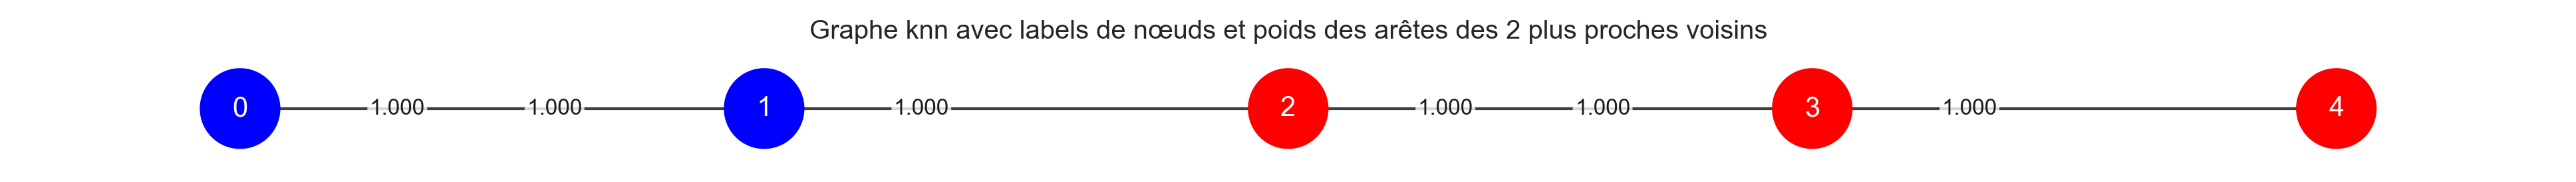

In [213]:
from IPython.display import Image, display

outpath = display_graph(kernel, X, G, y_propag, n_neighbors, path, filename, figsize=(13, 1))
display(Image(os.path.join(path, filename)))

In [214]:
# 5 points sur une ligne en 1D (on peut les embedder en 2D si on veut)
# dans un vrai problème, X serait ton vecteur de features (MFCC, pixels, embeddings, etc.).
X = np.array([[0.0],[1.0],[2.0],[3.0],[4.0]])
# labels : 1 = R, 5 = B, les autres inconnus
# on code R=0, B=1 pour scikit-learn`
kernel="rbf"
n_neighbors=2
filename="labelpropagRBF_Test.png"
y = np.array([0, -1, -1, -1, 1])
label_prop,y_propag, W, G = label_prop_function(
                                    kernel, X, y, 
                                    n_neighbors=n_neighbors, 
                                    gamma=1.0, flag=True
                                    )

W matrice de similarité RBF symétrique construite avec un noyau gaussien sur les points [[0. 1. 2. 3. 4.]].
['0.0000', '0.3679', '0.0183', '0.0001', '0.0000']
['0.3679', '0.0000', '0.3679', '0.0183', '0.0001']
['0.0183', '0.3679', '0.0000', '0.3679', '0.0183']
['0.0001', '0.0183', '0.3679', '0.0000', '0.3679']
['0.0000', '0.0001', '0.0183', '0.3679', '0.0000']


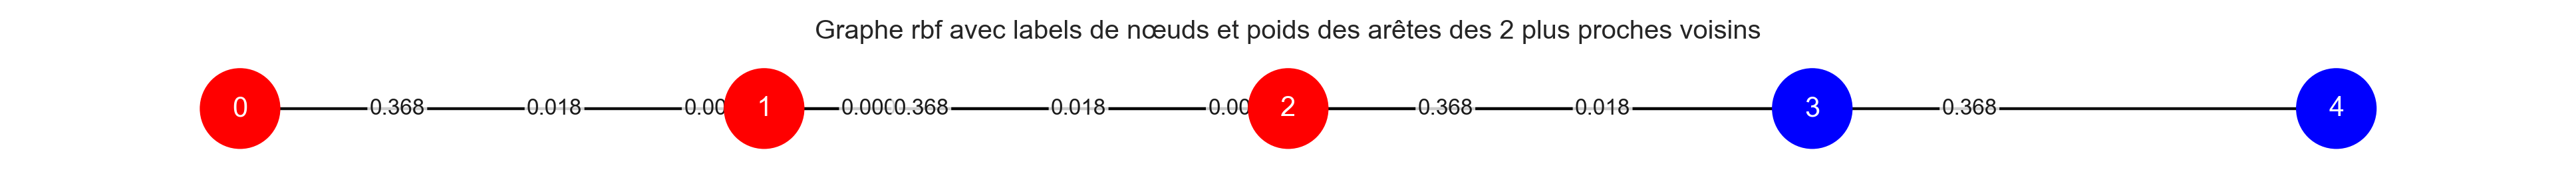

In [215]:
outpath = display_graph(kernel, X, G, y_propag, n_neighbors,path,filename,figsize=(13, 1))
from IPython.display import Image, display
display(Image(os.path.join(path, filename)))

In [216]:
# 1. Modèle + optimizer
del label_prop

import gc
gc.collect()

import torch
if device == "mps":
    torch.mps.empty_cache()   # sur Mac
elif device == "cuda":
    torch.cuda.empty_cache()   # sur NVidia 

In [217]:
kernel="knn"
n_neighbors=2
label_prop,y_propag, W, G = label_prop_function(
                                    kernel, X_train, y_train, 
                                    n_neighbors=n_neighbors, 
                                    gamma=0.9, flag=False
                                    )
y_pred = label_prop.predict(X_test)
acc = accuracy_score(y_pred,y_test)
print("Accuracy %.3f"%acc)

Accuracy 0.814


In [218]:
# 1. Modèle + optimizer
del label_prop

import gc
gc.collect()

import torch
if device == "mps":
    torch.mps.empty_cache()   # sur Mac
elif device == "cuda":
    torch.cuda.empty_cache()   # sur NVidia 

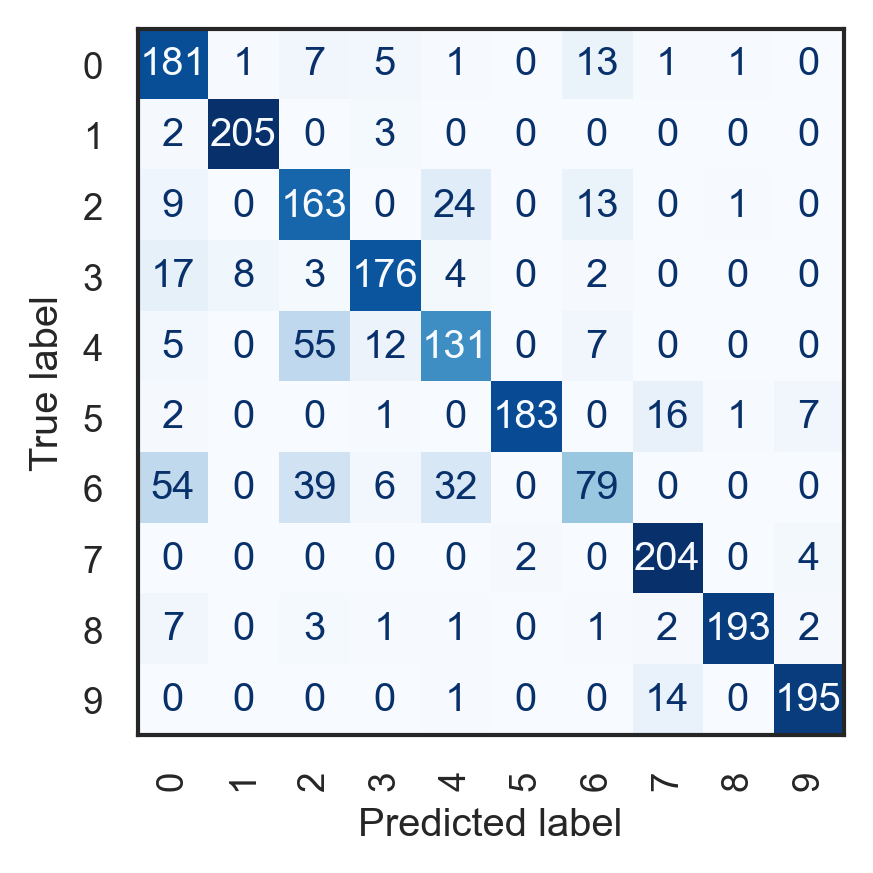

In [219]:
filename="cnfmatKNNLbl.png"
display_confusionMatrix(y_test,y_pred,num_classes,filename=filename)
from IPython.display import Image, display
display(Image(os.path.join(path, filename), width=300))

In [45]:
#help(SelfTrainingClassifier)

#### `Variantes`

- Essayer d'améliorer les performances du self-training / du modèle de base
- Essayer avec LabelSpreading au lieu de LabelPropagation

#### `LabelSpreading` 

C'est un algorithme de semi‑supervisé graph‑based avec « soft clamping » des labels initiaux, légèrement différent de LabelPropagation.

__Idée de base__
 - On construit un graphe de similarité entre tous les points (labellisés + non labellisés) à partir de leurs features X.
​ - On propage les labels connus le long des arêtes du graphe jusqu’à obtenir une distribution de probas 
$p(y∣x_i)$ pour chaque nœud.
 - Contrairement à LabelPropagation, LabelSpreading utilise une Laplacienne normalisée et mélange l’information des voisins avec l’information de départ (soft clamping contrôlé par alpha).

`kernel KNN`
__n_neighbors (pour knn) :__ 
 - Trop petit → graph fragmenté, risques de lignes nulles et instabilités; 
 - Trop grand → graphe trop dense, plus de bruit.
​
__alpha (clamping factor) :__
 - α=0 : on garde strictement les labels initiaux (ils ne bougent pas).
 - α=1 : les labels initiaux sont entièrement remplacés par l’info des voisins (hard label propagation).
 - 0.2 par défaut : compromis entre fidélité aux labels et adaptation à la structure du graphe.

__label_distributions_ :__
 - Matrice shape = (n_samples, n_classes) contenant les distributions de probas sur les classes pour chaque point.
​ - Utile si l'on veut filtrer les pseudo‑labels par confiance.

`y_labelled contient les vrais labels pour les points annotés et -1 pour les non annotés.`
​ - Après le fit, y_semi est un vecteur de taille len(X_train) avec un label pour chaque point (les -1 ont été remplacés).

In [220]:
from sklearn.semi_supervised import LabelSpreading
from sklearn.metrics import accuracy_score
import numpy as np

# 1) Semi-supervisé sur train (avec -1)
label_prop_model = LabelSpreading(
    kernel='knn',
    n_neighbors=20,
    max_iter=1000,
    alpha=0.9
)
label_prop_model.fit(X_train, y_labelled)
y_semi = label_prop_model.transduction_

# 2) Perf transductive sur les points labellisés
labeled_idx = np.where(y_labelled != -1)[0]
acc_trans = accuracy_score(
    np.asarray(y_train)[labeled_idx],
    np.asarray(y_semi)[labeled_idx]
)
print("Accuracy Train : %.3f" % acc_trans)

# 3) Perf inductive sur test
y_pred = label_prop_model.predict(X_test)
acc_test = accuracy_score(y_test, y_pred)
print("Accuracy test : %.3f" % acc_test)


Accuracy Train : 0.996
Accuracy test : 0.731


`Une accuracy de 0.735 est très bonne dans ce contexte` : 
 - Cela dit que, malgré que l'on ait que ~30 % de labels connus et 70 % inconnus. 
 - La propagation reconstruit ~73.5 % des labels sur les points labellisés que l'on utilise pour mesurer.

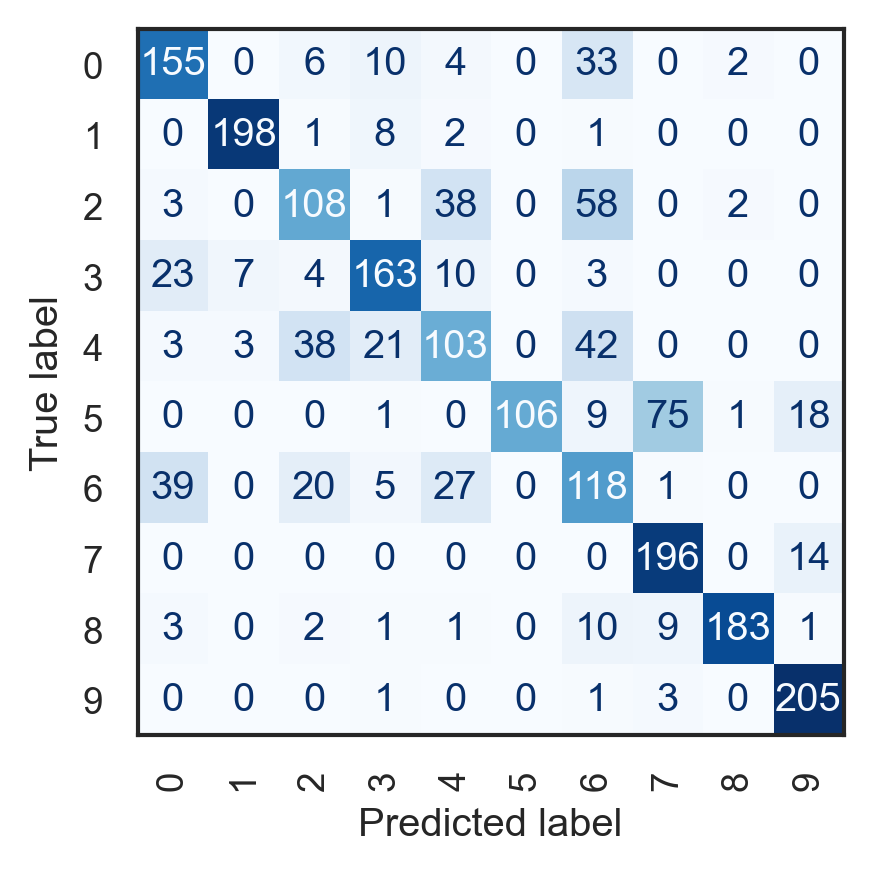

In [221]:
filename="cnfmatLblSpread.png"
display_confusionMatrix(y_test,y_pred,num_classes,filename=filename)
from IPython.display import Image, display
display(Image(os.path.join(path, filename), width=300))

In [222]:
# 1. Modèle + optimizer
del label_prop_model

import gc
gc.collect()

import torch
if device == "mps":
    torch.mps.empty_cache()   # sur Mac
elif device == "cuda":
    torch.cuda.empty_cache()   # sur NVidia 

`Quand ça marche bien (et quand ça n’apporte presque rien)`
__Bien :__
 - Structure de data très clusterisée, où des voisins proches partagent majoritairement la même classe (digits avec features décents, embeddings).
 - Peu de labels, beaucoup de non‑labellés, mais graphe fiable → bonnes perf transductives, parfois gains nets en test.
__Moins bien / quasi aucun gain :__
 - Hautes dimensions avec features bruts peu discriminants → le graphe kNN ne respecte pas les frontières de classe, d’où peu d’info utile à propager.
 - Pseudo‑labels assez bruités → un modèle supervisé ré‑entraîné dessus n’améliore pas (ce que l'on observe avec ~0.73–0.74)

`Conseils pratiques pour ton cas`
- Toujours scaler X avant LabelSpreading et la logistic (StandardScaler), sinon distances et optimisation sont bancales.
- Préférer kernel='knn' + n_neighbors dans sur tes features 784D, plus stable que RBF qui donne.
​ - Utiliser alpha petit (0.2–0.5) pour préserver les labels initiaux et éviter qu’ils soient trop corrigés par des voisins douteux.